# Predicción del precio por noche de Airbnb en NYC
### Proyecto end-to-end de Machine Learning con buenas prácticas

**Objetivo.** Estimar el precio por noche (`price`, USD) de un listing de Airbnb en Nueva York a partir de sus características, siguiendo el workflow de un proyecto profesional (estructura del cap. 2 de *Hands-On ML*, 3.ª ed.).

**Datos.** *New York City Airbnb Open Data* (Inside Airbnb, snapshot de julio de 2019): ~49k listings × 16 columnas.

**Modelos.** Regresión lineal, SVR (kernel RBF) y Random Forest, siempre comparados contra un baseline.

**Requisitos.** scikit-learn ≥ 1.4, pandas, numpy, scipy, matplotlib, joblib. Estructura de carpetas esperada:
```
proyecto/
├── data/AB_NYC_2019.csv
├── models/                 ← se crea al guardar el modelo (§10)
└── notebooks/este_notebook.ipynb
```
**Tiempo de ejecución.** ~26 min medidos con 1 núcleo de CPU; con varios núcleos baja bastante (el Random Forest y la CV del SVR se paralelizan). Lo más caro es el SVR (§6 y §7).

## Mapa del workflow

| # | Paso (HOML cap. 2) | Sección | Pregunta que responde |
|---|---|---|---|
| 1 | Look at the big picture | §1 Encuadre | ¿Qué se predice, para qué, y cómo se mide el éxito? |
| 2 | Get the data | §2 Carga e integridad | ¿Los datos son válidos? ¿Qué columnas se usan? |
| – | Create a test set | §3 Split | ¿Cómo garantizo una estimación honesta del error? |
| 3 | Explore the data | §4 EDA | ¿Qué patrones hay y qué decisiones implican? |
| 4 | Prepare the data | §5 Pipelines | ¿Cómo paso de datos crudos a features sin fugas? |
| 5 | Select and train models | §6 Screening | ¿Qué familias de modelos son prometedoras? |
| 6 | Fine-tune | §7 Ajuste fino | ¿Qué hiperparámetros? ¿Cuál es el mejor modelo? |
| – | Analyze the best model | §8 Análisis de errores | ¿Dónde falla? ¿Es robusta la validación? |
| 7 | Present the solution | §9 Test, §11 Conclusiones | ¿Cuánto rinde en datos nuevos? ¿Qué limitaciones tiene? |
| 8 | Launch, monitor, maintain | §10 Persistencia | ¿Cómo se guarda, reutiliza y monitorea? |

### Principios que se aplican en todo el notebook
1. **El test set se usa una sola vez**, al final (§9). Todas las decisiones (features, modelo, hiperparámetros) se toman con validación cruzada sobre el training set.
2. **Todo lo que aprende de los datos vive dentro de un `Pipeline`** (imputación, escalado, encoding, clustering). Así, en cada fold de CV se ajusta solo con los datos de entrenamiento de ese fold → sin *data leakage*.
3. **Cada hallazgo del EDA se traduce en una decisión explícita** (registro de decisiones en §4.6).
4. **Siempre hay un baseline**: un modelo que no le gana a "predecir la mediana" no aporta nada.
5. **Reproducibilidad**: semilla fija, versiones impresas, rutas relativas, lista explícita de features.

## 0. Setup
Imports agrupados (stdlib → terceros) y toda la configuración en un solo lugar. Las versiones se imprimen porque, si alguien re-ejecuta el notebook y obtiene números distintos, es lo primero que hay que comparar.

In [1]:
# --- Biblioteca estándar ---
import json
import platform
import time
from pathlib import Path

# --- Terceros ---
import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from IPython.display import display
from scipy.stats import loguniform

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_absolute_error, median_absolute_error, r2_score,
                             root_mean_squared_error, root_mean_squared_log_error)
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.model_selection import (GroupKFold, KFold, RandomizedSearchCV,
                                     cross_val_predict, cross_validate, train_test_split)
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import (FunctionTransformer, OneHotEncoder, OrdinalEncoder,
                                   StandardScaler, TargetEncoder)
from sklearn.svm import SVR

In [2]:
# --- Configuración del proyecto ---
RANDOM_STATE = 42
DATA_PATH = Path("..") / "data" / "AB_NYC_2019.csv"
MODELS_DIR = Path("..") / "models"

TARGET = "price"
TEST_SIZE = 0.20
CV_FOLDS = 5
SCORING = "neg_root_mean_squared_log_error"   # RMSLE; sklearn maximiza scores → usa el negativo

# --- Constantes de dominio ---
SNAPSHOT_DATE = pd.Timestamp("2019-07-08")    # fecha del scrape (= última review del dataset)
NYC_CENTER = (40.7580, -73.9855)              # Times Square (lat, lon): referencia de "centro"

# TargetEncoder existe desde 1.3; el scorer de RMSLE desde 1.4
assert tuple(int(v) for v in sklearn.__version__.split(".")[:2]) >= (1, 4), \
    f"Se necesita scikit-learn >= 1.4 (instalada: {sklearn.__version__})"

plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.precision", 4)

print(f"Python {platform.python_version()} | numpy {np.__version__} | pandas {pd.__version__} | "
      f"scikit-learn {sklearn.__version__} | matplotlib {matplotlib.__version__}")

Python 3.14.7 | numpy 2.5.2 | pandas 3.0.5 | scikit-learn 1.9.0 | matplotlib 3.11.1


## 1. Encuadre del problema
Antes de escribir código hay que fijar **qué se optimiza y para qué**: eso determina la métrica, el diseño de validación y qué features son legítimas.

| Pregunta | Decisión |
|---|---|
| **Uso del modelo** (supuesto) | Herramienta de *pricing* para analistas de mercado u hosts: estimar el precio de mercado de un listing y detectar listings sobre- o sub-valuados. |
| **Escenario de predicción** | Listings del mismo mercado y período (snapshot 2019). Un host puede tener otros listings en el training, así que un split aleatorio por listing es válido. Si el objetivo fueran *hosts nuevos*, habría que validar por grupos: lo chequeamos en §8.4. |
| **Features legítimas** | Solo las que existen al momento de predecir para un listing publicado: ubicación, tipo de habitación, noches mínimas, disponibilidad, historial de reviews. |
| **Tipo de problema** | Supervisado, regresión, *batch* (los datos entran en memoria; no hay flujo continuo). |
| **Métrica principal** | **RMSLE**: RMSE sobre `log1p(price)`. Mide error **relativo**: errar por \$50 en un listing de \$80 es grave; en uno de \$1500, no. Además no queda dominada por la cola de precios extremos (hasta \$10.000). |
| **Métricas secundarias** | MAE y MedAE en dólares y MdAPE (error porcentual mediano): para comunicar en unidades de negocio. |
| **Baseline** | Predecir siempre la mediana del training (`DummyRegressor`). |

$$\text{RMSLE} = \sqrt{\frac{1}{m}\sum_{i=1}^{m}\big[\log(1+\hat y_i) - \log(1+y_i)\big]^2}$$

**Interpretación:** un error $\delta$ en escala log es un **factor multiplicativo** $e^{\delta}$. Con RMSLE = 0.40, la predicción típica se desvía un factor $e^{0.40} \approx 1.5$ del precio real.

## 2. Carga de datos y chequeos de integridad
Antes del split solo miramos **estructura**: tipos, nulos y valores *imposibles*. Distribuciones y correlaciones se miran recién en §4, **solo sobre el training set**: si decidimos transformaciones mirando todo el dataset, el test deja de ser "datos nuevos" (*data snooping*).

In [4]:
airbnb = pd.read_csv(DATA_PATH)
print(f"Filas: {airbnb.shape[0]:} | Columnas: {airbnb.shape[1]}")
airbnb.head(3)

Filas: 48895 | Columnas: 16


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.6475,-73.9724,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.7536,-73.9838,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.8090,-73.9419,Private room,150,3,0,NaN,NaN,1,365


In [4]:
airbnb.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [5]:
# Reglas de validez: cosas que son errores independientemente de la distribución de los datos
integrity_checks = pd.Series({
    "id duplicado": airbnb["id"].duplicated().sum(),
    "price <= 0": (airbnb[TARGET] <= 0).sum(),
    "latitud fuera de NYC": (~airbnb["latitude"].between(40.45, 40.95)).sum(),
    "longitud fuera de NYC": (~airbnb["longitude"].between(-74.30, -73.65)).sum(),
    "minimum_nights < 1": (airbnb["minimum_nights"] < 1).sum(),
    "availability_365 fuera de [0, 365]": (~airbnb["availability_365"].between(0, 365)).sum(),
    "last_review posterior al snapshot": (pd.to_datetime(airbnb["last_review"]) > SNAPSHOT_DATE).sum(),
}, name="filas con problema")
integrity_checks

id duplicado                           0
price <= 0                            11
latitud fuera de NYC                   0
longitud fuera de NYC                  0
minimum_nights < 1                     0
availability_365 fuera de [0, 365]     0
last_review posterior al snapshot      0
Name: filas con problema, dtype: int64

**Hallazgos**
- Los NaN están en `name`, `host_name` (no se usan), `last_review` y `reviews_per_month` (se analizan en §4.5).
- Hay 11 listings con `price = 0`. No es un outlier: es un **valor inválido del target** (un listing no se ofrece gratis). Se descarta de todo el dataset antes del split; como es una regla de validez fija y no algo aprendido de la distribución, no genera fuga.
- Distinto sería descartar precios "demasiado altos" con un criterio estadístico: eso sí es decidir con los datos, y además en producción el modelo va a recibir esos listings. **No lo hacemos**; el log del target (§4.1) ya amortigua su influencia.

**Columnas que entran al modelo**

| Columna | Decisión | Motivo |
|---|---|---|
| `id` | descartar | identificador, sin información |
| `name` | descartar (por ahora) | texto libre: requiere NLP; queda como mejora (§11) |
| `host_name` | descartar | dato personal que no generaliza |
| `host_id` | fuera de `X`; se guarda como `groups` | identificador; sirve para validar por host (§8.4) |
| `last_review` | transformar | → días desde la última review (§5.1) |
| resto | features | disponibles al momento de predecir |

In [5]:
n_before = len(airbnb)
airbnb = airbnb[airbnb[TARGET] > 0].reset_index(drop=True)
print(f"Eliminadas {n_before - len(airbnb)} filas con price <= 0 → quedan {len(airbnb):,}")

ID_COLS = ["id", "host_id"]
DROPPED_COLS = ["name", "host_name"]
FEATURES = ["neighbourhood_group", "neighbourhood", "latitude", "longitude", "room_type",
            "minimum_nights", "number_of_reviews", "last_review", "reviews_per_month",
            "calculated_host_listings_count", "availability_365"]

# Contrato de columnas: cada columna del CSV tiene un destino explícito
assert set(FEATURES) | set(ID_COLS) | set(DROPPED_COLS) | {TARGET} == set(airbnb.columns)

Eliminadas 11 filas con price <= 0 → quedan 48,884


In [6]:
airbnb.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='str')

## 3. Train/test split estratificado
El test set se separa **antes** del EDA. Estratificamos por **quintiles de `price`**: el target tiene cola pesada y queremos la misma proporción de listings baratos y caros en train y test (misma idea que `income_cat` en HOML; es también lo que hace por defecto `rsample` en R con targets numéricos). Estratificar por el target no filtra información al modelo: solo decide de qué lado cae cada fila.

In [7]:
price_bins, bin_edges = pd.qcut(airbnb[TARGET], q=5, labels=False, retbins=True)

train_set, test_set = train_test_split(
    airbnb, test_size=TEST_SIZE, stratify=price_bins, random_state=RANDOM_STATE)

# Para comparar: split puramente aleatorio con la misma semilla
_, test_random = train_test_split(airbnb, test_size=TEST_SIZE, random_state=RANDOM_STATE)

def bin_proportions(df):
    return price_bins.loc[df.index].value_counts(normalize=True).sort_index() * 100

split_comparison = pd.DataFrame({
    "Total (%)": bin_proportions(airbnb),
    "Test estratificado (%)": bin_proportions(test_set),
    "Test aleatorio (%)": bin_proportions(test_random),
})
split_comparison["Error estratificado (%)"] = (split_comparison["Test estratificado (%)"] / split_comparison["Total (%)"] - 1) * 100
split_comparison["Error aleatorio (%)"] = (split_comparison["Test aleatorio (%)"] / split_comparison["Total (%)"] - 1) * 100
split_comparison.index = [f"Q{i + 1}: ${bin_edges[i]:.0f}–{bin_edges[i + 1]:.0f}" for i in range(5)]
split_comparison.round(2)

,Total (%),Test estratificado (%),Test aleatorio (%),Error estratificado (%),Error aleatorio (%)
Q1: $10–60,20.56,20.56,21.03,-0.02,2.27
Q2: $60–90,20.12,20.12,20.04,-0.00,-0.41
Q3: $90–130,20.06,20.06,19.74,0.01,-1.57
Q4: $130–200,22.11,22.11,22.04,0.01,-0.32
Q5: $200–10000,17.15,17.15,17.15,0.01,0.01


In [8]:
# Chequeo: ¿las categorías principales también quedaron balanceadas (sin haberlas usado como estrato)?
for col in ["room_type", "neighbourhood_group"]:
    display(pd.DataFrame({
        "train (%)": train_set[col].value_counts(normalize=True) * 100,
        "test (%)": test_set[col].value_counts(normalize=True) * 100,
    }).round(2))

,train (%),test (%)
room_type,,
Entire home/apt,51.97,52.01
Private room,45.69,45.53
Shared room,2.34,2.46


,train (%),test (%)
neighbourhood_group,,
Manhattan,44.28,44.43
Brooklyn,41.10,41.15
Queens,11.56,11.73
Bronx,2.30,1.94
Staten Island,0.77,0.75


Con ~49k filas un split aleatorio ya es bastante representativo, pero la estratificación lleva el error de proporciones de los quintiles prácticamente a cero. En datasets chicos o con colas pesadas la diferencia puede ser grande. `room_type` y `neighbourhood_group` también quedan balanceados.

Separamos features, target y grupos. A partir de acá **`test_set` no se toca hasta §9**.

In [9]:
X_train, y_train = train_set[FEATURES].copy(), train_set[TARGET].copy()
X_test, y_test = test_set[FEATURES].copy(), test_set[TARGET].copy()
groups_train = train_set["host_id"].copy()   # solo para el chequeo de robustez de §8.4

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (39107, 11) | Test: (9777, 11)


## 4. Análisis exploratorio (solo training set)
El objetivo del EDA no es describir todo, sino **encontrar lo que cambia decisiones de modelado**. Cada subsección termina en *hallazgo → decisión*. Trabajamos sobre una copia para no modificar `train_set`.

In [10]:
eda = train_set.copy()
eda["log_price"] = np.log1p(eda[TARGET])

### 4.1 El target

count    39107.0
mean       153.3
std        245.2
min         10.0
1%          30.0
5%          40.0
25%         69.0
50%        106.0
75%        175.0
95%        359.0
99%        799.0
max      10000.0

Asimetría → price: 19.22 | log1p(price): 0.64
Listings > $1000: 0.49%


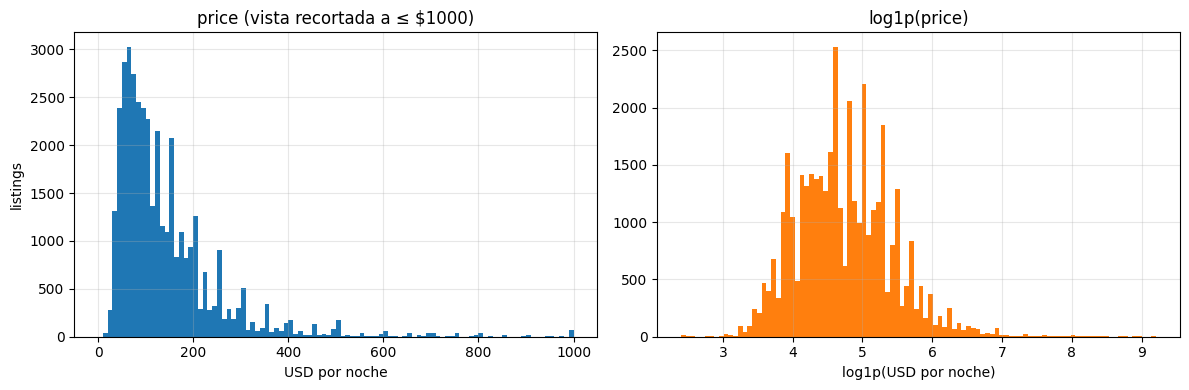

In [11]:
print(eda[TARGET].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).round(1).to_string())
print(f"\nAsimetría → price: {eda[TARGET].skew():.2f} | log1p(price): {eda['log_price'].skew():.2f}")
print(f"Listings > $1000: {(eda[TARGET] > 1000).mean():.2%}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(eda[TARGET], bins=100, range=(0, 1000), color="tab:blue")
axes[0].set(title="price (vista recortada a ≤ $1000)", xlabel="USD por noche", ylabel="listings")
axes[1].hist(eda["log_price"], bins=100, color="tab:orange")
axes[1].set(title="log1p(price)", xlabel="log1p(USD por noche)")
plt.tight_layout()
plt.show()

**Hallazgo.** `price` es extremadamente asimétrico (asimetría ≈ 19; rango \$10–\$10.000). En escala log la distribución es casi simétrica (con picos en precios "redondos" como \$100, \$150, \$200).

**Decisión.** Modelar `log1p(price)` con `TransformedTargetRegressor` (entrena en log, predice en dólares). Esto **cambia la función de pérdida**: minimizar el MSE en escala log es minimizar error relativo, coherente con la métrica RMSLE. Un escalado afín del target no tendría este efecto: solo cambia unidades.

### 4.2 Geografía
Proyectamos lat/lon a km con una proyección equirectangular local (en la escala de NYC el error es < 1 %). Así las distancias son euclídeas y con unidades físicas.

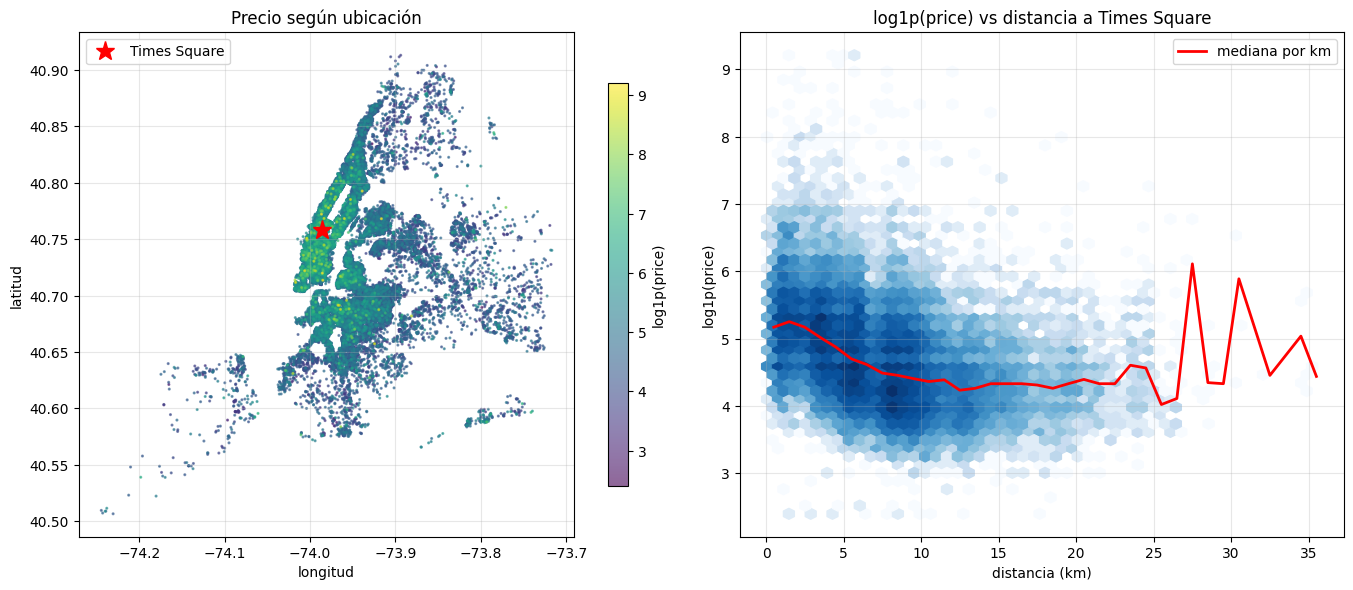

In [12]:
LAT0, LON0 = NYC_CENTER
KM_PER_DEG_LAT = 110.574                               # km por grado de latitud
KM_PER_DEG_LON = 111.320 * np.cos(np.radians(LAT0))   # km por grado de longitud a la latitud de NYC (~84 km)

def to_local_km(lat, lon):
    """Proyección equirectangular local centrada en Times Square → (x, y) en km."""
    return (lon - LON0) * KM_PER_DEG_LON, (lat - LAT0) * KM_PER_DEG_LAT

x_km, y_km = to_local_km(eda["latitude"], eda["longitude"])
eda["dist_center_km"] = np.hypot(x_km, y_km)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={"width_ratios": [1.1, 1]})
order = eda["log_price"].sort_values().index   # los listings caros se dibujan arriba
sc = axes[0].scatter(eda.loc[order, "longitude"], eda.loc[order, "latitude"],
                     c=eda.loc[order, "log_price"], s=1.5, cmap="viridis", alpha=0.6)
axes[0].plot(LON0, LAT0, marker="*", color="red", markersize=14, linestyle="none", label="Times Square")
axes[0].set_aspect(1 / np.cos(np.radians(LAT0)))   # mapa sin distorsión: 1° lon = cos(lat)·1° lat
axes[0].set(title="Precio según ubicación", xlabel="longitud", ylabel="latitud")
axes[0].legend(loc="upper left")
fig.colorbar(sc, ax=axes[0], label="log1p(price)", shrink=0.8)

axes[1].hexbin(eda["dist_center_km"], eda["log_price"], gridsize=50, bins="log", cmap="Blues", mincnt=1)
median_by_km = eda.groupby(pd.cut(eda["dist_center_km"], bins=np.arange(0, 37, 1)), observed=True)["log_price"].median()
axes[1].plot([interval.mid for interval in median_by_km.index], median_by_km.values, color="red", lw=2, label="mediana por km")
axes[1].set(title="log1p(price) vs distancia a Times Square", xlabel="distancia (km)", ylabel="log1p(price)")
axes[1].legend()
plt.tight_layout()
plt.show()

**Hallazgo.** El precio decae con la distancia a Midtown (los primeros ~10 km concentran la caída), con estructura local (Lower Manhattan, Williamsburg) que una sola distancia no captura. Latitud y longitud por separado no tienen una relación monótona con el precio.

**Decisión.** Features derivadas: coordenadas en km, `dist_center_km` y, para los modelos lineales, similitud a clusters geográficos (§5.2). El Random Forest puede usar lat/lon crudas porque parte el espacio con cortes.

### 4.3 Variables categóricas
Para medir asociación categórica → numérica, Pearson no sirve. Usamos la **razón de correlación** $\eta^2 = SS_{\text{entre}}/SS_{\text{total}}$ (= R² de regresar `log_price` sobre el one-hot completo). Como $\eta^2$ crece con el número de categorías aunque no haya señal, reportamos también $\omega^2$, que corrige ese sesgo.

In [13]:
def association_ratio(categories, y):
    """η² (correlation ratio) y ω² (corrige el sesgo positivo de η², que crece con el nº de categorías)."""
    groups = y.groupby(categories, observed=True)
    n, k = len(y), groups.ngroups
    ss_total = ((y - y.mean()) ** 2).sum()
    ss_between = (groups.size() * (groups.mean() - y.mean()) ** 2).sum()
    ms_within = (ss_total - ss_between) / (n - k)
    return pd.Series({
        "n categorías": k,
        "η²": ss_between / ss_total,
        "ω²": (ss_between - (k - 1) * ms_within) / (ss_total + ms_within),
    })

cat_assoc = pd.DataFrame({col: association_ratio(eda[col], eda["log_price"])
                          for col in ["room_type", "neighbourhood_group", "neighbourhood"]}).T
cat_assoc["n categorías"] = cat_assoc["n categorías"].astype(int)
display(cat_assoc.sort_values("ω²", ascending=False).round(3))

neigh_counts = eda["neighbourhood"].value_counts()
print(f"neighbourhoods con < 10 listings en train: {(neigh_counts < 10).sum()} de {len(neigh_counts)}")

print("\nPrecio mediano (USD) por borough y tipo de habitación:")
display(eda.pivot_table(index="neighbourhood_group", columns="room_type", values=TARGET, aggfunc="median").round(0))

,n categorías,η²,ω²
room_type,3,0.382,0.382
neighbourhood,220,0.276,0.272
neighbourhood_group,5,0.131,0.131


neighbourhoods con < 10 listings en train: 64 de 220

Precio mediano (USD) por borough y tipo de habitación:


room_type,Entire home/apt,Private room,Shared room
neighbourhood_group,,,
Bronx,100.0,55.0,38.0
Brooklyn,145.0,65.0,35.0
Manhattan,190.0,90.0,69.0
Queens,120.0,60.0,38.0
Staten Island,105.0,52.0,30.0


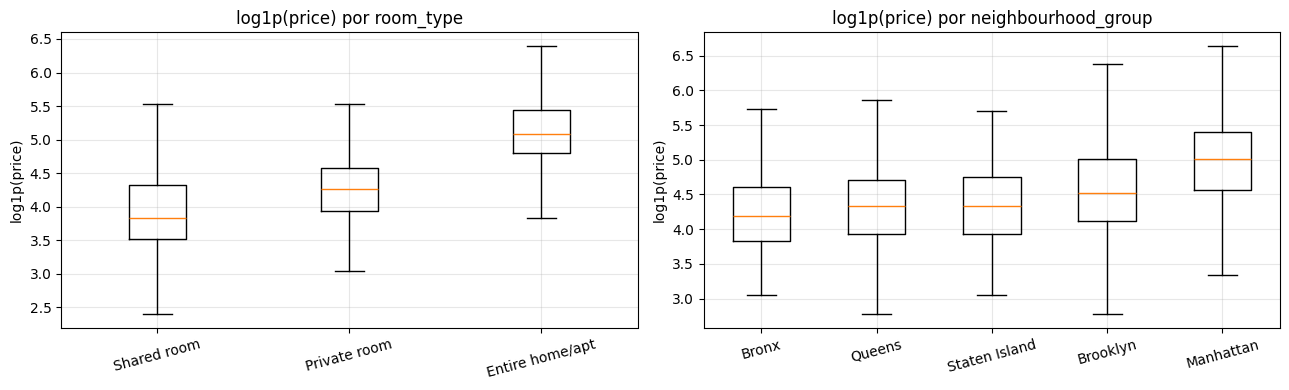

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col in zip(axes, ["room_type", "neighbourhood_group"]):
    categories = eda.groupby(col)["log_price"].median().sort_values().index
    ax.boxplot([eda.loc[eda[col] == c, "log_price"] for c in categories], showfliers=False)
    ax.set_xticks(range(1, len(categories) + 1), categories, rotation=15)
    ax.set(title=f"log1p(price) por {col}", ylabel="log1p(price)")
plt.tight_layout()
plt.show()

**Hallazgos.**
- `room_type` es la variable más informativa (ω² ≈ 0.38): una casa entera cuesta ~2× una habitación privada en cualquier borough.
- `neighbourhood` también es muy informativa (ω² ≈ 0.27), pero tiene 220 categorías y 64 con menos de 10 listings en train: un one-hot crearía ~220 columnas ralas con coeficientes mal estimados.
- `neighbourhood_group` aporta menos y es en gran parte redundante con `neighbourhood`.

**Decisión.** One-hot (modelos lineales) u ordinal (árboles) para `room_type` y `neighbourhood_group`; **target encoding** con *shrinkage* y *cross-fitting* para `neighbourhood` (§5.3).

### 4.4 Variables numéricas
Usamos correlación de **Spearman** (sobre rangos): capta relaciones monótonas aunque no sean lineales, es robusta a outliers y no depende de si la variable está en log o no. Pearson queda como contraste.

In [15]:
num_cols = ["minimum_nights", "number_of_reviews", "reviews_per_month", "calculated_host_listings_count",
            "availability_365", "latitude", "longitude", "dist_center_km"]
num_summary = pd.DataFrame({
    "asimetría": eda[num_cols].skew(),
    "ρ Spearman vs log_price": eda[num_cols].corrwith(eda["log_price"], method="spearman"),
    "r Pearson vs log_price": eda[num_cols].corrwith(eda["log_price"]),
})
display(num_summary.sort_values("ρ Spearman vs log_price", key=np.abs, ascending=False).round(3))

print(f"availability_365 == 0: {(eda['availability_365'] == 0).mean():.1%} de los listings")
print(f"minimum_nights ≥ 30: {(eda['minimum_nights'] >= 30).mean():.1%} | > 365 noches: {(eda['minimum_nights'] > 365).sum()} listings")
print(f"Máximo de listings de un mismo host en train: {eda['host_id'].value_counts().max()}")

,asimetría,ρ Spearman vs log_price,r Pearson vs log_price
dist_center_km,1.024,-0.457,-0.389
longitude,1.293,-0.439,-0.326
latitude,0.240,0.132,0.075
calculated_host_listings_count,8.033,-0.108,0.131
minimum_nights,22.873,0.102,0.033
availability_365,0.763,0.086,0.100
number_of_reviews,3.686,-0.057,-0.047
reviews_per_month,3.348,-0.021,-0.041


availability_365 == 0: 35.9% de los listings
minimum_nights ≥ 30: 9.3% | > 365 noches: 10 listings
Máximo de listings de un mismo host en train: 250


**Hallazgos.**
- `dist_center_km` (feature derivada) es la numérica más asociada con el precio (ρ ≈ −0.46), por encima de lat/lon crudas.
- Los conteos (`minimum_nights`, `number_of_reviews`, `calculated_host_listings_count`, `reviews_per_month`) son muy asimétricos (asimetrías de 3 a 23) y tienen asociaciones débiles.
- `availability_365` tiene una masa puntual en 0 (~36 %, listings inactivos o bloqueados).
- Hay hosts con cientos de listings: sus precios están correlacionados entre sí (lo retomamos en §8.4).

**Decisión.** `log1p` + estandarización de los conteos **solo en el pipeline lineal/SVR**: los árboles son invariantes a transformaciones monótonas. Los valores extremos de `minimum_nights` se conservan (el log los comprime; el árbol los aísla con un corte).

### 4.5 Valores faltantes
Antes de imputar hay que entender **por qué** falta el dato (MCAR / MAR / MNAR o faltante estructural).

In [16]:
missing = X_train.isna().sum()
display(missing[missing > 0].rename("NaN en train"))

no_reviews = eda["number_of_reviews"] == 0
display(pd.crosstab(no_reviews.rename("number_of_reviews == 0"),
                    eda["reviews_per_month"].isna().rename("reviews_per_month es NaN")))

# Verificación explícita: los NaN coinciden exactamente con "0 reviews"
assert (eda["reviews_per_month"].isna() == no_reviews).all()
assert (eda["last_review"].isna() == no_reviews).all()

last_review          8024
reviews_per_month    8024
Name: NaN en train, dtype: int64

reviews_per_month es NaN,False,True
number_of_reviews == 0,,
False,31083,0
True,0,8024


**Hallazgo.** Los NaN de `reviews_per_month` y `last_review` coinciden **exactamente** con `number_of_reviews == 0`: no es información perdida, es un **faltante estructural** (no hay reviews que promediar ni fecha que registrar).

**Decisión.**
- `reviews_per_month` → 0 (su valor verdadero, no una imputación estadística).
- `days_since_last_review` (derivada de `last_review`) no tiene un valor "verdadero" sin reviews → imputación por mediana **+ indicador binario** de faltante, para que el modelo pueda tratar ese grupo aparte.

### 4.6 Registro de decisiones

| Hallazgo (EDA en train) | Decisión | Dónde |
|---|---|---|
| `price` con asimetría ≈ 19 (\$10–\$10.000) | Target `log1p` vía `TransformedTargetRegressor`; métrica RMSLE; no se eliminan outliers | §5.4, §6 |
| El precio cae con la distancia a Midtown | Proyección a km + `dist_center_km` | §5.1 |
| Estructura geográfica local no monótona | Similitud RBF a clusters (lineal/SVR); lat/lon crudas (RF) | §5.2–5.3 |
| `room_type` domina; `neighbourhood` con ~220 niveles, muchos raros | One-hot/ordinal para baja cardinalidad; `TargetEncoder` para `neighbourhood` | §5.3 |
| Conteos muy asimétricos | `log1p` + `StandardScaler` solo en lineal/SVR | §5.3 |
| NaN ⇔ 0 reviews (faltante estructural) | `reviews_per_month` → 0; recencia → mediana + indicador | §5.1, §5.3 |
| Hosts con cientos de listings | Chequeo de validación agrupada por host | §8.4 |

## 5. Preparación de datos: todo dentro de un Pipeline
Distinguimos dos tipos de transformaciones:
- **Sin estado** (§5.1): no aprenden nada de los datos (p. ej. la distancia a Times Square). Cada fila se transforma sola, así que no pueden filtrar información.
- **Con estado** (§5.2–5.3): aprenden parámetros (medianas, medias y desvíos, centros de clusters, encodings). **Tienen** que ajustarse solo con datos de entrenamiento: viven dentro del Pipeline, que se re-ajusta en cada fold de CV.

Ambas van dentro del Pipeline final para que el modelo guardado reciba **datos crudos** y haga todo el procesamiento, igual que en producción.

### 5.1 Features sin estado

In [17]:
def build_features(X):
    """Features derivadas SIN estado: no hay parámetros aprendidos, así que no hay riesgo de fuga.
    Igual van dentro del Pipeline para que el modelo final acepte datos crudos."""
    X = X.copy()
    X["x_km"], X["y_km"] = to_local_km(X["latitude"], X["longitude"])
    X["dist_center_km"] = np.hypot(X["x_km"], X["y_km"])
    X["days_since_last_review"] = (SNAPSHOT_DATE - pd.to_datetime(X["last_review"])).dt.days  # NaN si no hay reviews
    X["reviews_per_month"] = X["reviews_per_month"].fillna(0.0)   # faltante estructural: 0 reviews ⇒ 0 por mes
    return X

build_features(X_train.head(3))[["x_km", "y_km", "dist_center_km", "days_since_last_review", "reviews_per_month"]]

,x_km,y_km,dist_center_km,days_since_last_review,reviews_per_month
28742,3.2017,-13.7797,14.1468,214.0,0.50
45709,8.5696,10.6295,13.6537,NaN,0.00
38124,2.0979,-3.0872,3.7326,184.0,0.27


### 5.2 Transformador propio: similitud a clusters geográficos
Adaptamos el `ClusterSimilarity` de HOML: K-Means sobre las coordenadas y, como features, la similitud RBF $e^{-\gamma \lVert \mathbf{x} - \mathbf{c}_j \rVert^2}$ a cada centro $\mathbf{c}_j$. Le da a un modelo lineal una forma de representar "zonas", que no son funciones lineales de lat/lon.

Dos cambios respecto del libro, ambos de **unidades**:
1. **Coordenadas en km, no en grados.** En NYC un grado de longitud mide ~84 km y uno de latitud ~111 km: en grados, K-Means y el kernel RBF son anisótropos. En km la métrica es euclídea de verdad.
2. **γ con unidades.** HOML usa γ = 1 con grados en California (escala ~10°). En NYC las distancias entre zonas son ~0.02–0.05°: con γ = 1 en grados, $e^{-\gamma d^2} \approx 1$ para todos los puntos y la feature sería constante. En km, γ = 0.2 km⁻² ⇒ $\sigma = 1/\sqrt{2\gamma} \approx 1.6$ km, el tamaño típico de un barrio.

In [18]:
class ClusterSimilarity(BaseEstimator, TransformerMixin):
    """Similitud RBF a los centros de K-Means (adaptado de HOML cap. 2). Espera coordenadas en km."""

    def __init__(self, n_clusters=25, gamma=0.2, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma                  # en km⁻²
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_ = KMeans(self.n_clusters, n_init=10, random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self                         # siempre devolver self

    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)

    def get_feature_names_out(self, names=None):
        return [f"cluster_{i}_similarity" for i in range(self.n_clusters)]

### 5.3 Dos preprocesamientos: uno por familia de modelos
La familia de modelos decide qué preprocesamiento es necesario. Transformar de más no rompe nada, pero agrega complejidad sin beneficio.

| Componente | LR / SVR | Random Forest | Por qué |
|---|---|---|---|
| Conteos asimétricos | `log1p` + `StandardScaler` | nada | Los árboles son invariantes a transformaciones monótonas |
| Escala | `StandardScaler` | nada | El kernel RBF del SVR depende de distancias entre features. OLS no (es equivariante a transformaciones afines), pero no le molesta |
| Geografía | similitud a clusters + distancia | lat/lon crudas + distancia | El árbol corta el espacio; el lineal necesita features que representen zonas |
| `room_type`, `neighbourhood_group` | One-hot | Ordinal | Los árboles pueden usar códigos enteros; en lineal, un orden arbitrario no tiene sentido |
| `neighbourhood` (~220 niveles) | `TargetEncoder` + escala | `TargetEncoder` | Alta cardinalidad (ver abajo) |
| `days_since_last_review` | `log1p` → mediana + indicador → escala | mediana + indicador | Faltante con significado (§4.5) |

**`TargetEncoder`** reemplaza cada categoría por la media del target (acá, `log1p(price)`) en esa categoría, "encogida" hacia la media global cuando la categoría tiene pocos datos (*shrinkage*). Riesgo: si una fila se codifica con una media que incluye su propio target, el modelo ve la respuesta. Por eso `fit_transform` usa **cross-fitting** interno (cada fila se codifica con medias calculadas sin ella) y, al estar dentro del Pipeline, además se re-aprende en cada fold de CV.

In [19]:
log_then_scale = make_pipeline(FunctionTransformer(np.log1p, feature_names_out="one-to-one"), StandardScaler())

recency_pipeline = make_pipeline(
    FunctionTransformer(np.log1p, feature_names_out="one-to-one"),
    SimpleImputer(strategy="median", add_indicator=True),   # + columna binaria "no tenía reviews"
    StandardScaler(),
)

preprocessing_linear = ColumnTransformer([
    ("log_counts", log_then_scale, ["minimum_nights", "number_of_reviews", "reviews_per_month",
                                    "calculated_host_listings_count", "dist_center_km"]),
    ("recency", recency_pipeline, ["days_since_last_review"]),
    ("availability", StandardScaler(), ["availability_365"]),
    ("geo_clusters", ClusterSimilarity(n_clusters=25, gamma=0.2, random_state=RANDOM_STATE), ["x_km", "y_km"]),
    ("low_card_cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ["room_type", "neighbourhood_group"]),
    ("neighbourhood", make_pipeline(TargetEncoder(random_state=RANDOM_STATE), StandardScaler()), ["neighbourhood"]),
], remainder="drop")

preprocessing_tree = ColumnTransformer([
    ("numeric", SimpleImputer(strategy="median", add_indicator=True),
     ["latitude", "longitude", "dist_center_km", "minimum_nights", "number_of_reviews", "reviews_per_month",
      "calculated_host_listings_count", "availability_365", "days_since_last_review"]),
    ("low_card_cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
     ["room_type", "neighbourhood_group"]),
    ("neighbourhood", TargetEncoder(random_state=RANDOM_STATE), ["neighbourhood"]),
], remainder="drop")

### 5.4 El modelo completo: datos crudos → predicción en dólares
`TransformedTargetRegressor` (TTR) envuelve el Pipeline:
- `fit(X, y)`: calcula `log1p(y)` y ajusta el Pipeline sobre eso.
- `predict(X)`: devuelve `expm1(pipeline.predict(X))`, es decir, dólares.

Consecuencia práctica: evaluar las predicciones en dólares con RMSLE es exactamente el RMSE en la escala en que el modelo se entrenó.

In [20]:
def make_model(preprocessing, regressor):
    """Datos crudos → features sin estado → preprocesamiento → regresor, entrenado sobre log1p(price)."""
    pipeline = Pipeline([
        ("features", FunctionTransformer(build_features)),
        ("preprocessing", clone(preprocessing)),
        ("model", regressor),
    ])
    return TransformedTargetRegressor(regressor=pipeline, func=np.log1p, inverse_func=np.expm1)

**Sanity check:** antes de evaluar nada, conviene mirar **qué ve realmente el modelo**: número de columnas, nombres, escalas. Muchos bugs de preprocesamiento se detectan acá.

In [21]:
demo = make_model(preprocessing_linear, LinearRegression()).fit(X_train, y_train)
fitted_pipeline = demo.regressor_                    # el Pipeline ajustado dentro del TTR
feature_names = fitted_pipeline.named_steps["preprocessing"].get_feature_names_out()
X_seen = fitted_pipeline[:-1].transform(X_train.head(3))   # todo el pipeline menos el modelo

print(f"Pipeline lineal/SVR: {X_seen.shape[1]} features")
print(f"Pipeline de árboles: {make_model(preprocessing_tree, DummyRegressor()).fit(X_train, y_train).regressor_.named_steps['preprocessing'].get_feature_names_out().size} features")
pd.DataFrame(X_seen, columns=feature_names).T.round(3)

Pipeline lineal/SVR: 42 features
Pipeline de árboles: 13 features


,0,1,2
log_counts__minimum_nights,-0.461,-0.926,-0.461
log_counts__number_of_reviews,0.054,-1.276,-0.573
log_counts__reviews_per_month,-0.239,-0.940,-0.527
log_counts__calculated_host_listings_count,0.828,-0.460,-0.460
log_counts__dist_center_km,1.312,1.257,-0.622
recency__days_since_last_review,0.719,-0.156,0.627
recency__missingindicator_days_since_last_review,-0.508,1.968,-0.508
availability__availability_365,-0.857,0.934,-0.857
geo_clusters__cluster_0_similarity,0.002,0.000,0.004
geo_clusters__cluster_1_similarity,0.000,0.000,0.000


## 6. Selección de modelos (screening)
Probamos cada familia con hiperparámetros por defecto para ver cuáles son prometedoras **antes** de invertir tiempo en ajustarlas.

**Diseño de validación.** K-fold con k = 5, `shuffle=True` y semilla fija. Todas las comparaciones usan **los mismos folds**, así las diferencias entre modelos no se deben a particiones distintas. Registramos también el error de **entrenamiento**: la brecha train–validación diagnostica sub- o sobreajuste.

**Paralelismo en un solo nivel.** El Random Forest ya paraleliza internamente (árboles en paralelo, `n_jobs=-1` en el modelo). El SVR (libsvm) usa un solo núcleo, así que para él paralelizamos los folds (`n_jobs=-1` en la CV). Paralelizar en ambos niveles a la vez sobre-suscribe la CPU.

In [22]:
cv = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

def evaluate_cv(model, n_jobs=None):
    """CV k-fold sobre el training set: RMSLE de entrenamiento y de validación por fold."""
    res = cross_validate(model, X_train, y_train, cv=cv, scoring=SCORING,
                         return_train_score=True, n_jobs=n_jobs)
    return {"train": -res["train_score"], "cv": -res["test_score"], "fit_time": res["fit_time"]}

candidates = {   # nombre: (modelo, n_jobs de la CV)
    "Baseline (mediana)": (make_model(preprocessing_tree, DummyRegressor(strategy="median")), None),
    "Linear Regression": (make_model(preprocessing_linear, LinearRegression()), None),
    "SVR (RBF)": (make_model(preprocessing_linear, SVR(kernel="rbf", C=1.0, epsilon=0.1, gamma="scale")), -1),
    "Random Forest": (make_model(preprocessing_tree, RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)), None),
}

screening = {}
for name, (model, n_jobs) in candidates.items():
    t0 = time.perf_counter()
    screening[name] = evaluate_cv(model, n_jobs=n_jobs)
    print(f"{name:<20} RMSLE CV = {screening[name]['cv'].mean():.4f} ± {screening[name]['cv'].std():.4f}"
          f"   ({time.perf_counter() - t0:.0f} s)")

Baseline (mediana)   RMSLE CV = 0.6962 ± 0.0051   (0 s)


Linear Regression    RMSLE CV = 0.4632 ± 0.0039   (3 s)


SVR (RBF)            RMSLE CV = 0.4440 ± 0.0043   (504 s)


Random Forest        RMSLE CV = 0.4416 ± 0.0030   (108 s)


,RMSLE train,RMSLE CV,std CV,brecha (CV − train),fit medio (s)
Baseline (mediana),0.6962,0.6962,0.0051,-0.0000,0.0455
Linear Regression,0.4615,0.4632,0.0039,0.0017,0.5279
SVR (RBF),0.4284,0.4440,0.0043,0.0156,42.2802
Random Forest,0.2079,0.4416,0.0030,0.2338,20.5711


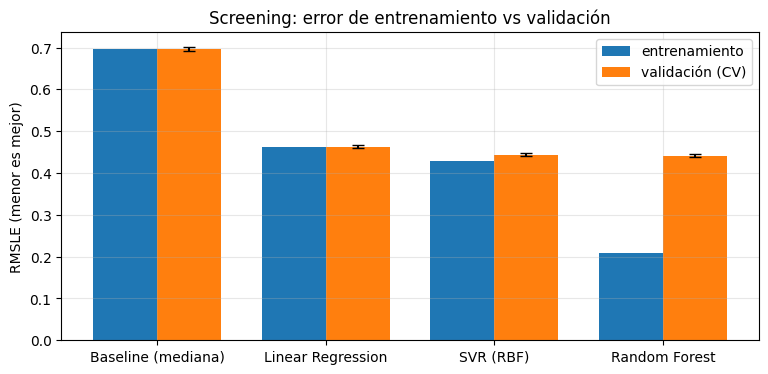

In [23]:
screening_df = pd.DataFrame({
    name: {"RMSLE train": r["train"].mean(), "RMSLE CV": r["cv"].mean(), "std CV": r["cv"].std(),
           "brecha (CV − train)": r["cv"].mean() - r["train"].mean(), "fit medio (s)": r["fit_time"].mean()}
    for name, r in screening.items()
}).T
display(screening_df.round(4))

fig, ax = plt.subplots(figsize=(9, 4))
pos, width = np.arange(len(screening_df)), 0.38
ax.bar(pos - width / 2, screening_df["RMSLE train"], width, label="entrenamiento")
ax.bar(pos + width / 2, screening_df["RMSLE CV"], width, yerr=screening_df["std CV"], capsize=4, label="validación (CV)")
ax.set_xticks(pos, screening_df.index)
ax.set(ylabel="RMSLE (menor es mejor)", title="Screening: error de entrenamiento vs validación")
ax.legend()
plt.show()

**Diagnóstico (lectura estilo HOML):**
- **Baseline** (RMSLE ≈ 0.70): factor típico de error $e^{0.70} \approx 2$. Todo modelo tiene que ganarle con claridad.
- **Regresión lineal** (≈ 0.46): train ≈ CV → **subajuste** (sesgo alto). Más datos no la van a mejorar; haría falta más capacidad (interacciones, p. ej. `room_type` × zona) o un modelo más flexible.
- **SVR** (≈ 0.44): el kernel RBF captura no linealidades; la brecha train–CV es moderada. **Costo**: su ajuste es órdenes de magnitud más lento que el lineal.
- **Random Forest** (≈ 0.44): error de train muy bajo (≈ 0.21) → **sobreajuste** (varianza alta), pero aun así el mejor en validación. Regularizarlo (`min_samples_leaf`, `max_features`) puede ayudar.

**Finalistas para el ajuste fino: Random Forest y SVR.** La regresión lineal queda como modelo de referencia interpretable.

## 7. Ajuste fino de hiperparámetros
Usamos `RandomizedSearchCV` en vez de `GridSearchCV`: con varios hiperparámetros, muestrear combinaciones al azar explora mejor el espacio con el mismo presupuesto y admite distribuciones continuas.

Los nombres de los parámetros siguen la anidación de objetos: `regressor__model__max_features` = TTR → `regressor` (el Pipeline) → paso `model` → parámetro `max_features`.

### 7.1 Random Forest
- `max_features`: fracción de features candidatas en cada corte. Menos candidatas → árboles más distintos entre sí → menor varianza del promedio.
- `min_samples_leaf`: tamaño mínimo de hoja. Regulariza (árboles menos profundos).
- `max_samples`: fracción del bootstrap por árbol. Más diversidad y entrenamiento más rápido.
- `n_estimators` queda **fijo en 200**: en un RF, más árboles nunca empeoran la generalización (solo reducen varianza, con rendimientos decrecientes). No es algo a optimizar, sino un compromiso costo/estabilidad.

La búsqueda usa CV de 3 folds (más barata); el ganador se re-evalúa con los 5 folds estándar en §7.3.

In [24]:
search_cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

rf_model = make_model(preprocessing_tree,
                      RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1))
rf_param_distributions = {
    "regressor__model__max_features": [0.2, 0.33, 0.5, 0.7, 1.0],
    "regressor__model__min_samples_leaf": [1, 2, 4, 8, 16],
    "regressor__model__max_samples": [0.5, 0.75, None],
}
rf_search = RandomizedSearchCV(rf_model, rf_param_distributions, n_iter=12, cv=search_cv, scoring=SCORING,
                               random_state=RANDOM_STATE, refit=False)   # refit en §9, con el modelo ya elegido
t0 = time.perf_counter()
rf_search.fit(X_train, y_train)
print(f"Búsqueda RF: {time.perf_counter() - t0:.0f} s | mejor RMSLE (CV 3 folds) = {-rf_search.best_score_:.4f}")

Búsqueda RF: 366 s | mejor RMSLE (CV 3 folds) = 0.4365


In [25]:
def search_summary(search, top=5):
    """Top combinaciones de una búsqueda, con nombres cortos de parámetros."""
    results = pd.DataFrame(search.cv_results_)
    params = pd.DataFrame([{k.split("__")[-1]: ("None" if v is None else v) for k, v in p.items()}
                           for p in results["params"]])
    params["RMSLE CV"] = -results["mean_test_score"]
    params["std"] = results["std_test_score"]
    params["fit medio (s)"] = results["mean_fit_time"]
    return params.sort_values("RMSLE CV").head(top).reset_index(drop=True)

search_summary(rf_search).round(4)

,min_samples_leaf,max_samples,max_features,RMSLE CV,std,fit medio (s)
0,4,None,0.50,0.4365,0.0058,12.0710
1,1,0.75,0.50,0.4374,0.0059,13.7153
2,2,0.5,1.00,0.4380,0.0052,16.8132
3,1,None,0.20,0.4382,0.0049,8.0847
4,8,None,0.33,0.4385,0.0054,7.5113


### 7.2 SVR: búsqueda en una submuestra
El SVR con kernel escala entre $O(m^2 n)$ y $O(m^3 n)$ con el número de instancias $m$ (HOML cap. 5, tabla 5-1): en el screening, cada ajuste con ~31k filas tardó ~40 s, contra ~0.5 s de la regresión lineal. Una búsqueda completa sería muy costosa, así que (como hace HOML en los ejercicios del cap. 2) **buscamos en una submuestra de 8.000 filas** y después evaluamos la mejor combinación con el training completo (§7.3).

Limitación: el óptimo en 8k filas no es exactamente el óptimo en 31k (con más datos suele convenir menos regularización, es decir, `C` mayor).

- `C`: inversa de la fuerza de regularización.
- `gamma`: inversa del radio del kernel RBF (en unidades de features estandarizadas).
- `epsilon`: ancho del tubo sin penalización, **en unidades de log-precio**: ε = 0.1 ≈ ±10 % de precio sin costo.

In [26]:
svr_model = make_model(preprocessing_linear, SVR(kernel="rbf"))
svr_param_distributions = {
    "regressor__model__C": loguniform(0.1, 10),
    "regressor__model__gamma": loguniform(0.005, 0.5),
    "regressor__model__epsilon": loguniform(0.02, 0.5),
}
svr_subset = X_train.sample(n=8_000, random_state=RANDOM_STATE).index

svr_search = RandomizedSearchCV(svr_model, svr_param_distributions, n_iter=15, cv=search_cv, scoring=SCORING,
                                random_state=RANDOM_STATE, refit=False, n_jobs=-1)
t0 = time.perf_counter()
svr_search.fit(X_train.loc[svr_subset], y_train.loc[svr_subset])
print(f"Búsqueda SVR: {time.perf_counter() - t0:.0f} s | mejor RMSLE (submuestra, CV 3 folds) = {-svr_search.best_score_:.4f}")
search_summary(svr_search).round(4)

Búsqueda SVR: 76 s | mejor RMSLE (submuestra, CV 3 folds) = 0.4524


,C,epsilon,gamma,RMSLE CV,std,fit medio (s)
0,0.7591,0.0296,0.0489,0.4524,0.0082,1.3499
1,4.6226,0.0396,0.0116,0.4525,0.0060,1.3100
2,0.7310,0.0511,0.0837,0.4540,0.0085,1.2593
3,0.8168,0.2504,0.0125,0.4541,0.0054,0.7355
4,1.5751,0.0330,0.0103,0.4546,0.0049,1.2091


### 7.3 Comparación final con CV de 5 folds (predicciones out-of-fold)
Re-evaluamos los finalistas ajustados **con los mismos 5 folds del screening** usando `cross_val_predict`: cada fila del training recibe una predicción de un modelo que **no la vio** (predicciones *out-of-fold*, OOF). Sirven para dos cosas: el score de CV y el análisis de errores de §8 sin tocar el test.

La comparación es **pareada** (fold a fold): un fold "difícil" lo es para todos los modelos, así que la *diferencia* entre modelos tiene mucha menos varianza que cada score por separado (el ruido correlacionado se cancela en la resta).

In [27]:
def oof_evaluate(model, n_jobs=None):
    """Predicciones out-of-fold + RMSLE por fold (mismos folds que el screening)."""
    oof = cross_val_predict(model, X_train, y_train, cv=cv, n_jobs=n_jobs)
    fold_scores = np.array([root_mean_squared_log_error(y_train.iloc[val], oof[val])
                            for _, val in cv.split(X_train)])
    return oof, fold_scores

finalists = {   # nombre: (modelo, n_jobs de la CV, hiperparámetros elegidos)
    "Linear Regression": (candidates["Linear Regression"][0], None, {}),
    "SVR (ajustado)": (clone(svr_model).set_params(**svr_search.best_params_), -1, svr_search.best_params_),
    "Random Forest (ajustado)": (clone(rf_model).set_params(**rf_search.best_params_), None, rf_search.best_params_),
}
oof_preds, fold_scores = {}, {}
for name, (model, n_jobs, _) in finalists.items():
    t0 = time.perf_counter()
    oof_preds[name], fold_scores[name] = oof_evaluate(model, n_jobs)
    print(f"{name:<26} RMSLE CV = {fold_scores[name].mean():.4f} ± {fold_scores[name].std():.4f}"
          f"   ({time.perf_counter() - t0:.0f} s)")

Linear Regression          RMSLE CV = 0.4632 ± 0.0039   (3 s)


SVR (ajustado)             RMSLE CV = 0.4469 ± 0.0044   (282 s)


Random Forest (ajustado)   RMSLE CV = 0.4350 ± 0.0034   (77 s)


In [28]:
best_name = min(fold_scores, key=lambda n: fold_scores[n].mean())
best_model = finalists[best_name][0]
best_oof = oof_preds[best_name]

final_comparison = pd.DataFrame({
    "RMSLE CV": {n: s.mean() for n, s in fold_scores.items()},
    "std entre folds": {n: s.std() for n, s in fold_scores.items()},
    "Δ pareada vs mejor": {n: (s - fold_scores[best_name]).mean() for n, s in fold_scores.items()},
    "std de Δ": {n: (s - fold_scores[best_name]).std() for n, s in fold_scores.items()},
    "folds en que pierde": {n: int((s > fold_scores[best_name]).sum()) for n, s in fold_scores.items()},
})
display(final_comparison.round(4))

tuning_gain = pd.DataFrame({
    "por defecto (§6)": [screening["SVR (RBF)"]["cv"].mean(), screening["Random Forest"]["cv"].mean()],
    "ajustado (§7)": [fold_scores["SVR (ajustado)"].mean(), fold_scores["Random Forest (ajustado)"].mean()],
}, index=["SVR", "Random Forest"])
tuning_gain["mejora"] = tuning_gain["por defecto (§6)"] - tuning_gain["ajustado (§7)"]
display(tuning_gain.round(4))
print(f"Modelo elegido: {best_name}")

,RMSLE CV,std entre folds,Δ pareada vs mejor,std de Δ,folds en que pierde
Linear Regression,0.4632,0.0039,0.0282,0.0012,5
SVR (ajustado),0.4469,0.0044,0.0119,0.0015,5
Random Forest (ajustado),0.4350,0.0034,0.0000,0.0000,0


,por defecto (§6),ajustado (§7),mejora
SVR,0.4440,0.4469,-0.0029
Random Forest,0.4416,0.4350,0.0066


Modelo elegido: Random Forest (ajustado)


**Decisión y lecturas.**
- El **Random Forest ajustado** gana en los 5 folds; la diferencia con el SVR es chica en valor absoluto pero consistente (la std de la diferencia pareada es mucho menor que la diferencia). Además predice mucho más rápido que el SVR, que tiene que evaluar el kernel contra decenas de miles de vectores de soporte.
- **El ajuste fino dio poco.** En el RF mejoró ~0.007 en RMSLE (parte se debe a pasar de 100 a 200 árboles). En el **SVR empeoró** (~0.003): los hiperparámetros óptimos en la submuestra de 8k no lo son con 31k filas. Es la limitación anticipada en §7.2: la búsqueda eligió un `C` menor que el default, cuando con más datos conviene uno mayor. Lección: un resultado de búsqueda se re-valida en las condiciones reales. Y cuando el paisaje de hiperparámetros es plano, el techo lo pone **la información en las features**, no los hiperparámetros.
- El `best_score_` de una búsqueda es optimista (se eligió el máximo entre muchos candidatos ruidosos). La estimación sin sesgo la da el test set en §9; la alternativa rigurosa sin test sería *nested CV*.

## 8. Análisis del modelo elegido (todavía sin test)
Antes de mirar el test, entender **dónde y por qué** falla el modelo. Todo con datos de training: predicciones OOF (§8.1–8.2), una partición interna de validación (§8.3) y un esquema de CV alternativo (§8.4).

### 8.1 Residuos out-of-fold

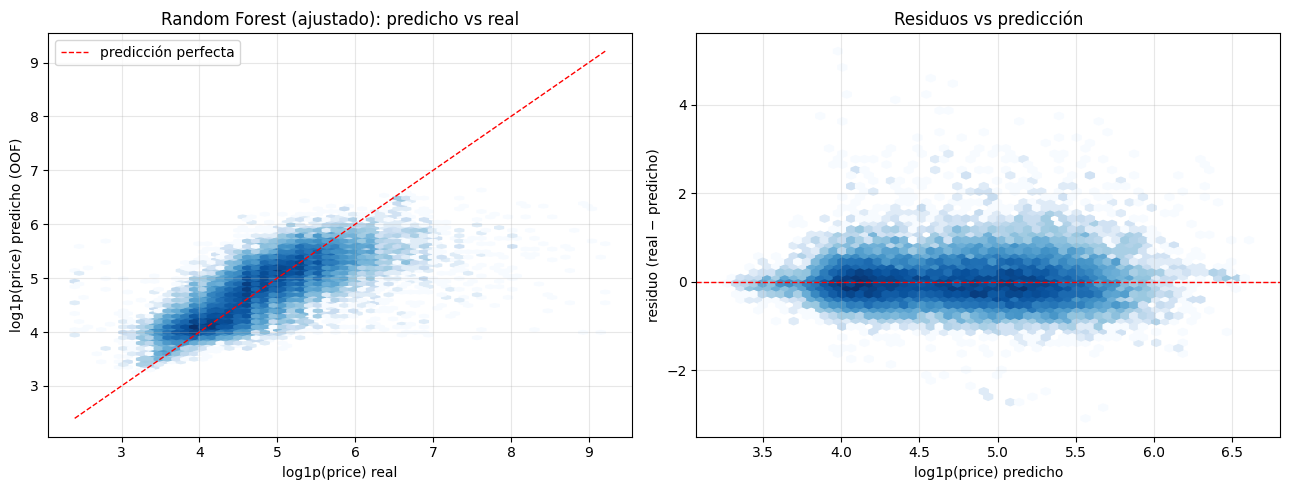

Rango de predicciones OOF: $25–$760 | rango real: $10–$10000


In [29]:
log_true, log_pred = np.log1p(y_train), np.log1p(best_oof)
residuals = log_true - log_pred       # > 0: el modelo subestima el precio

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hexbin(log_true, log_pred, gridsize=60, bins="log", cmap="Blues", mincnt=1)
lims = [log_true.min(), log_true.max()]
axes[0].plot(lims, lims, "r--", lw=1, label="predicción perfecta")
axes[0].set(xlabel="log1p(price) real", ylabel="log1p(price) predicho (OOF)", title=f"{best_name}: predicho vs real")
axes[0].legend()
axes[1].hexbin(log_pred, residuals, gridsize=60, bins="log", cmap="Blues", mincnt=1)
axes[1].axhline(0, color="r", ls="--", lw=1)
axes[1].set(xlabel="log1p(price) predicho", ylabel="residuo (real − predicho)", title="Residuos vs predicción")
plt.tight_layout()
plt.show()

print(f"Rango de predicciones OOF: ${best_oof.min():.0f}–${best_oof.max():.0f} | "
      f"rango real: ${y_train.min():.0f}–${y_train.max():.0f}")

**Lectura.** Las predicciones están **comprimidas hacia el centro**: el modelo nunca predice menos de ~\$25 ni más de ~\$760, aunque en los datos haya precios de \$10 a \$10.000. Los residuos contra la predicción están centrados en 0 y sin tendencia marcada (no hay un sesgo sistemático que una transformación simple corrija), pero con mucha dispersión: gran parte de la variación del precio depende de información que no está en el dataset (tamaño, amenities, fotos, calidad).

### 8.2 Errores por segmento
Útil para comunicar a negocio *para qué casos* el modelo es confiable.

In [30]:
errors = pd.DataFrame({
    "room_type": X_train["room_type"],
    "neighbourhood_group": X_train["neighbourhood_group"],
    "quintil de precio real": pd.qcut(y_train, 5),
    "sq_log_err": residuals ** 2,
    "log_resid": residuals,
    "abs_err_usd": (y_train - best_oof).abs(),
})

def segment_report(col):
    g = errors.groupby(col, observed=True)
    return pd.DataFrame({
        "n": g.size(),
        "RMSLE": np.sqrt(g["sq_log_err"].mean()),
        "sesgo medio (log)": g["log_resid"].mean(),
        "MAE ($)": g["abs_err_usd"].mean(),
    })

for col in ["room_type", "neighbourhood_group", "quintil de precio real"]:
    display(segment_report(col).round(3))

,n,RMSLE,sesgo medio (log),MAE ($)
room_type,,,,
Entire home/apt,20322,0.462,-0.002,81.369
Private room,17868,0.398,0.002,31.023
Shared room,917,0.486,-0.053,29.092


,n,RMSLE,sesgo medio (log),MAE ($)
neighbourhood_group,,,,
Bronx,900,0.433,-0.039,31.131
Brooklyn,16072,0.422,0.000,45.040
Manhattan,17316,0.454,-0.000,75.960
Queens,4519,0.404,-0.003,34.073
Staten Island,300,0.480,-0.044,44.562


,n,RMSLE,sesgo medio (log),MAE ($)
quintil de precio real,,,,
"(9.999, 60.0]",8042,0.392,-0.269,16.943
"(60.0, 90.0]",7868,0.319,-0.091,22.392
"(90.0, 130.0]",7843,0.343,-0.086,34.034
"(130.0, 200.0]",8647,0.327,0.037,40.499
"(200.0, 10000.0]",6707,0.724,0.473,194.575


**Lectura.**
- Las **habitaciones compartidas** tienen el mayor error relativo. Entre boroughs, los peores son Staten Island (el de menos datos) y Manhattan (el mercado más heterogéneo).
- Por quintil de precio real aparece el patrón de **regresión a la media**: sobreestima los baratos (sesgo < 0) y subestima los caros (sesgo > 0). Parte es un artefacto esperable de condicionar en el valor real cuando hay ruido; la otra parte indica que falta información para distinguir un listing de lujo de uno promedio en la misma zona.

### 8.3 Importancia de features por permutación
Se permuta una columna (se rompe su relación con el target) y se mide cuánto empeora el RMSLE. Ventajas frente a `feature_importances_` del RF: se calcula sobre **datos no vistos**, sirve para cualquier modelo y opera sobre **columnas crudas** (`neighbourhood` cuenta como una sola). La impureza del RF, en cambio, se calcula en training y favorece a las variables continuas o de alta cardinalidad.

Para no usar el test, separamos una **validación interna** del training (80/20).

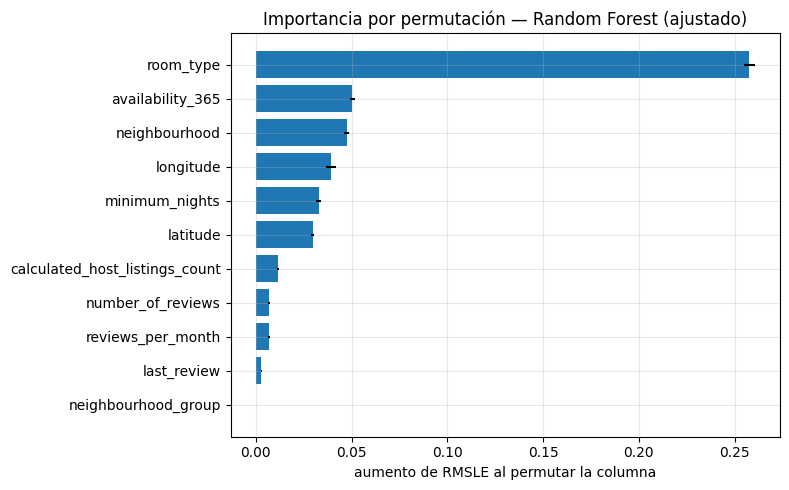

In [31]:
X_fit, X_val, y_fit, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=RANDOM_STATE)
model_for_importance = clone(best_model).fit(X_fit, y_fit)

perm = permutation_importance(model_for_importance, X_val, y_val, scoring=SCORING,
                              n_repeats=5, random_state=RANDOM_STATE)
importances = pd.DataFrame({"aumento de RMSLE": perm.importances_mean, "std": perm.importances_std},
                           index=X_val.columns).sort_values("aumento de RMSLE")

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importances.index, importances["aumento de RMSLE"], xerr=importances["std"], color="tab:blue")
ax.set(xlabel="aumento de RMSLE al permutar la columna", title=f"Importancia por permutación — {best_name}")
plt.tight_layout()
plt.show()

**Lectura.** `room_type` domina. Le siguen `availability_365` (llamativo: su ρ de Spearman era débil, ≈ 0.09, así que el RF la usa de forma no monótona o en interacción con otras) y las variables de ubicación. Cuidado al interpretar: las variables de ubicación (`latitude`, `longitude`, `neighbourhood`, `neighbourhood_group`) son redundantes entre sí, y al permutar una sola el modelo compensa con las demás. Por eso la importancia **individual** de cada una subestima la del bloque "ubicación"; `neighbourhood_group` sale ≈ 0 justamente porque su información ya está en las otras.

### 8.4 Chequeo de robustez del diseño de validación: ¿hosts nuevos?
En §4.4 vimos hosts con cientos de listings. Sus precios están correlacionados (mismo operador, edificios similares) y un modelo flexible puede "reconocer" al host: `calculated_host_listings_count` = 327, por ejemplo, identifica a un único operador. Con K-fold aleatorio, los listings de un mismo host caen en train y validación a la vez.

¿Es fuga? **Depende del escenario** (§1). Si el modelo se usa para listings de hosts ya presentes en los datos, no lo es. Si se usa para **hosts nuevos**, sí: la CV sería optimista. `GroupKFold` por `host_id` simula ese escenario (ningún host aparece en train y validación a la vez).

In [32]:
group_cv = GroupKFold(n_splits=CV_FOLDS)
robustness = {}
for name in ["Linear Regression", best_name]:
    model, n_jobs, _ = finalists[name]
    res = cross_validate(model, X_train, y_train, groups=groups_train, cv=group_cv, scoring=SCORING, n_jobs=n_jobs)
    robustness[name] = {"KFold (listings al azar)": fold_scores[name].mean(),
                        "GroupKFold (hosts nuevos)": -res["test_score"].mean()}

robustness_df = pd.DataFrame(robustness).T
robustness_df["degradación"] = robustness_df["GroupKFold (hosts nuevos)"] - robustness_df["KFold (listings al azar)"]
robustness_df.round(4)

,KFold (listings al azar),GroupKFold (hosts nuevos),degradación
Linear Regression,0.4632,0.4648,0.0016
Random Forest (ajustado),0.4350,0.4494,0.0144


**Lectura.** La regresión lineal casi no cambia; el Random Forest empeora bastante más. Una parte de su ventaja viene de **memorizar patrones de hosts** que también están en validación. Implicaciones:
- Para el escenario definido (hosts existentes), la estimación de K-fold es válida.
- Para hosts nuevos, habría que usar `GroupKFold` también en la búsqueda de hiperparámetros y un split train/test por grupos (`GroupShuffleSplit`), y esperar un error mayor.

Esta es una decisión de **diseño de validación**, y ningún algoritmo la toma por uno: sale del encuadre del problema.

## 9. Evaluación final en el test set
Reglas: (1) el modelo y sus hiperparámetros ya están congelados; (2) se reentrena con **todo** el training set; (3) se evalúa **una sola vez**. Si después de ver el test cambiáramos algo, el test pasaría a ser otro set de validación y perderíamos la estimación honesta.

El baseline se evalúa solo como referencia (no se elige nada con él).

In [33]:
final_model = clone(best_model).fit(X_train, y_train)
y_pred_test = final_model.predict(X_test)

baseline_model = clone(candidates["Baseline (mediana)"][0]).fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)

def regression_report(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    return pd.Series({
        "RMSLE": root_mean_squared_log_error(y_true, y_pred),
        "R² (escala log)": r2_score(np.log1p(y_true), np.log1p(y_pred)),
        "MdAPE (%)": np.median(np.abs(y_pred - y_true) / y_true) * 100,
        "MAE ($)": mean_absolute_error(y_true, y_pred),
        "MedAE ($)": median_absolute_error(y_true, y_pred),
        "RMSE ($)": root_mean_squared_error(y_true, y_pred),
    })

test_report = pd.DataFrame({
    "Baseline (mediana)": regression_report(y_test, y_pred_baseline),
    best_name: regression_report(y_test, y_pred_test),
})
display(test_report.round(3))
print(f"RMSLE estimado por CV: {fold_scores[best_name].mean():.4f} | RMSLE en test: {test_report.loc['RMSLE', best_name]:.4f}")

,Baseline (mediana),Random Forest (ajustado)
RMSLE,0.688,0.421
R² (escala log),-0.008,0.623
MdAPE (%),44.211,23.027
MAE ($),81.939,53.859
MedAE ($),46.000,23.209
RMSE ($),223.566,199.472


RMSLE estimado por CV: 0.4350 | RMSLE en test: 0.4208


Una métrica sin incertidumbre está incompleta. Estimamos intervalos de confianza del 95 % con **bootstrap**: re-muestrear el test con reposición y recalcular la métrica (*Practical Statistics*, cap. 2).

In [34]:
rng = np.random.default_rng(RANDOM_STATE)
y_true_arr = y_test.to_numpy()
sq_log_err = (np.log1p(y_true_arr) - np.log1p(y_pred_test)) ** 2
abs_err = np.abs(y_true_arr - y_pred_test)

boot_idx = rng.integers(0, len(y_true_arr), size=(1000, len(y_true_arr)))   # 1000 re-muestras
boot_rmsle = np.sqrt(sq_log_err[boot_idx].mean(axis=1))
boot_mae = abs_err[boot_idx].mean(axis=1)

pd.DataFrame({
    "estimación": [np.sqrt(sq_log_err.mean()), abs_err.mean()],
    "IC 95% inferior": [np.percentile(boot_rmsle, 2.5), np.percentile(boot_mae, 2.5)],
    "IC 95% superior": [np.percentile(boot_rmsle, 97.5), np.percentile(boot_mae, 97.5)],
}, index=["RMSLE", "MAE ($)"]).round(3)

,estimación,IC 95% inferior,IC 95% superior
RMSLE,0.421,0.407,0.433
MAE ($),53.859,50.345,58.047


In [35]:
# Sesgo de retransformación: expm1(E[log y]) no es E[y]
print(f"Precio medio en test → real: ${y_true_arr.mean():.1f} | predicho: ${y_pred_test.mean():.1f}")

Precio medio en test → real: $150.6 | predicho: $131.7


**Interpretación para negocio.**
- El RMSLE en test (0.421) es algo **mejor** que la estimación de CV (0.435), que queda apenas por encima del IC 95 % [0.407, 0.433]. No es señal de un problema: el modelo final se entrenó con todo el training (39k filas, contra ~31k en cada fold de CV) y el test tiene su propio ruido de muestreo. Lo importante es que no es peor: no hubo sobreajuste a la validación.
- RMSLE ≈ 0.42 ⇒ factor típico de error $e^{0.42} \approx 1.5$. La mitad de las predicciones está a menos de ~23 % del precio real (MdAPE); el error absoluto mediano es de ~\$23.
- El RMSE en dólares es alto porque lo dominan unos pocos listings de miles de dólares: por eso no es la métrica principal.

**Sesgo de retransformación.** El modelo aproxima $\mathbb{E}[\log(1+y)\mid x]$, y por la desigualdad de Jensen $e^{\mathbb{E}[\log y]} \le \mathbb{E}[y]$: las predicciones se parecen más a la **mediana condicional** que a la media, así que el precio medio predicho queda por debajo del real. Para errores relativos (el objetivo del §1) es lo correcto. Si negocio necesitara totales en dólares (p. ej. ingresos agregados), habría que corregirlo (*smearing estimator* de Duan) o entrenar directamente sobre dólares.

## 10. Guardar el modelo y usarlo con datos nuevos
Se guarda el **pipeline completo** (features + preprocesamiento + modelo + transformación del target), junto con metadatos para trazabilidad: qué datos, qué hiperparámetros, qué métricas y qué versiones de librerías.

In [36]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)
model_path = MODELS_DIR / "airbnb_nyc_price_model.joblib"
joblib.dump(final_model, model_path, compress=3)

metadata = {
    "modelo": best_name,
    "hiperparametros": {k.split("__")[-1]: v for k, v in finalists[best_name][2].items()},
    "features_de_entrada": FEATURES,
    "target": "price (USD/noche); se entrena sobre log1p(price) y se predice en USD",
    "datos": {"archivo": DATA_PATH.name, "snapshot": str(SNAPSHOT_DATE.date()),
              "n_train": len(X_train), "n_test": len(X_test)},
    "metricas": {"rmsle_cv_5fold": float(fold_scores[best_name].mean()),
                 **{f"test_{k}": float(v) for k, v in test_report[best_name].items()}},
    "versiones": {"python": platform.python_version(), "scikit-learn": sklearn.__version__,
                  "pandas": pd.__version__, "numpy": np.__version__},
    "fecha_entrenamiento": pd.Timestamp.now().isoformat(timespec="seconds"),
}
metadata_path = MODELS_DIR / "airbnb_nyc_price_model.json"
metadata_path.write_text(json.dumps(metadata, indent=2, ensure_ascii=False, default=str), encoding="utf-8")
print(f"Modelo: {model_path} ({model_path.stat().st_size / 1e6:.1f} MB) | Metadatos: {metadata_path}")

Modelo: ../models/airbnb_nyc_price_model.joblib (48.3 MB) | Metadatos: ../models/airbnb_nyc_price_model.json


In [37]:
# Uso: cargar y predecir sobre datos CRUDOS (mismas columnas que FEATURES)
loaded_model = joblib.load(model_path)

new_listings = pd.DataFrame([
    {"neighbourhood_group": "Brooklyn", "neighbourhood": "Williamsburg", "latitude": 40.7140, "longitude": -73.9580,
     "room_type": "Entire home/apt", "minimum_nights": 3, "number_of_reviews": 25, "last_review": "2019-06-20",
     "reviews_per_month": 1.2, "calculated_host_listings_count": 1, "availability_365": 150},
    {"neighbourhood_group": "Manhattan", "neighbourhood": "Midtown", "latitude": 40.7560, "longitude": -73.9860,
     "room_type": "Private room", "minimum_nights": 1, "number_of_reviews": 0, "last_review": None,
     "reviews_per_month": None, "calculated_host_listings_count": 2, "availability_365": 300},
])[FEATURES]

new_listings.assign(precio_estimado_usd=loaded_model.predict(new_listings).round(0))

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,precio_estimado_usd
0,Brooklyn,Williamsburg,40.714,-73.958,Entire home/apt,3,25,2019-06-20,1.2,1,150,223.0
1,Manhattan,Midtown,40.756,-73.986,Private room,1,0,NaN,NaN,2,300,148.0


**Notas para producción**
- **Código reutilizable fuera del notebook.** `joblib` guarda funciones y clases *por referencia* (módulo + nombre). Como `build_features`, `to_local_km` y `ClusterSimilarity` están definidas en el notebook (`__main__`), cargar el modelo desde otro script falla salvo que se definan de nuevo. En un repo real van en un módulo (p. ej. `src/features.py`) que se importa tanto al entrenar como al predecir.
- **Git.** `data/` y `models/` van al `.gitignore`: son archivos grandes o derivados. Se versiona el código que los genera, no los artefactos.
- **Monitoreo.** Vigilar *data drift* (barrios nuevos, cambios en la distribución de features y de precios; el mercado post-2019 cambió mucho), medir el error real cuando se observan precios nuevos y reentrenar periódicamente con el mismo pipeline.

## 11. Conclusiones, limitaciones y próximos pasos

**Resultado.** Un Random Forest sobre `log1p(price)` alcanza RMSLE ≈ 0.42 en test (factor de error típico ≈ 1.5, error porcentual mediano ≈ 23 %), frente a ≈ 0.69 del baseline en test y ≈ 0.46 de la regresión lineal en CV. El SVR queda cerca (≈ 0.44 en CV), pero es mucho más caro de entrenar y de usar.

**Lecciones de workflow**
1. **El encuadre define todo lo demás**: la métrica (RMSLE ↔ error relativo ↔ target en log) y la validación (listings vs hosts nuevos, §8.4) salen de cómo se va a usar el modelo.
2. **Pipelines = cero fugas por construcción** y un único artefacto que va de datos crudos a predicción.
3. **Primero screening, después tuning.** El ajuste fino dio mejoras chicas; las ganancias grandes vinieron del target en log y de features con sentido de dominio (distancia al centro, target encoding).
4. **Diagnóstico train vs CV** para saber si el problema es sesgo (lineal) o varianza (RF).
5. **El costo computacional es parte de la decisión** (SVR: $O(m^2)$–$O(m^3)$).
6. **Test una sola vez**, con intervalo de confianza.

**Limitaciones**
- Faltan los drivers principales del precio (metros cuadrados, dormitorios, amenities, fotos): el techo de error viene de ahí.
- Datos de 2019: el mercado cambió (pandemia y la regulación de alquileres de corto plazo de NYC en 2023). No usar este modelo para precios actuales sin reentrenar.
- Para hosts nuevos el error esperado es mayor (§8.4).

**Próximos pasos (en orden de impacto esperado)**
1. **Features de texto** a partir de `name` (TF-IDF): contiene "2BR", "luxury", "studio", "loft", señales directas de tamaño y calidad.
2. **Gradient boosting** (`HistGradientBoostingRegressor`, cap. 7 de HOML): suele superar al RF en datos tabulares.
3. Validación agrupada por host si el caso de uso incluye hosts nuevos.
4. Intervalos de predicción (regresión cuantílica) para comunicar incertidumbre por listing.

**Transferencia.** El esqueleto (encuadre → split → EDA en train → pipeline → screening → tuning → análisis → test una vez) es el mismo en pharma o salud pública. Lo que cambia es el encuadre y, sobre todo, la validación: el equivalente del "host" suele ser el **paciente, el centro clínico o el lote**, y separar por grupo ahí no es opcional.